# 1. Gradient descent

The gist: write down the error, differentiate it, move in the direction that makes the error smaller.

In [3]:
!wget -O workshop_utils.py https://raw.githubusercontent.com/wjpearson/vistula/main/arazim/workshop_utils.py

--2026-09-22 10:19:07--  https://raw.githubusercontent.com/wjpearson/vistula/main/arazim/workshop_utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3487 (3.4K) [text/plain]
Saving to: ‘workshop_utils.py’

workshop_utils.py   100%[===================>]   3.41K  --.-KB/s    in 0s      

2026-09-22 10:19:07 (33.9 MB/s) - ‘workshop_utils.py’ saved [3487/3487]



In [5]:
# --- setup ------------------------------------------------
import sys, os, urllib.request

sys.path.append("..")          # if you cloned the repo, the helper is one level up
if not os.path.exists("workshop_utils.py") and "workshop_utils" not in sys.modules:
    try:
        import workshop_utils
    except ImportError:        # we are on Colab: fetch the helper
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/ShrRa/vistula_workshop/main/workshop_utils.py",
            "workshop_utils.py")

import numpy as np
import matplotlib.pyplot as plt
import workshop_utils as wu

np.random.seed(0)   # so that everyone in the room sees the same plots
plt.rcParams["figure.figsize"] = (5, 4)

## 1. Downhill by hand

Take a func:

$$f(x) = x^2 \qquad\qquad \frac{df}{dx} = 2x$$

The derivative $df/dx$ is the **slope** of the curve at the point
$x$ -- how much $f$ goes up if you take a tiny step to the right. If the slope
is positive the curve is rising, so to go **down** we must step to the
**left**, and vice versa.

The update rule:

$$x_{\text{new}} = x_{\text{old}} - \eta \cdot \frac{df}{dx}(x_{\text{old}})$$

The number $\eta$ (eta) is the **learning rate**.

In [6]:
def f(x):
    return x ** 2

def df(x):
    """The slope of f at x, worked out with a pencil."""
    return 2 * x


x = 3.0          # where we start, aka 'initial guess'
lr = 0.1         # eta, the learning rate

print(f"{'step':>4} {'x':>9} {'f(x)':>9} {'slope':>9}") # f-string - scary looking way to print things prettily
for step in range(6):
    print(f"{step:>4} {x:>9.4f} {f(x):>9.4f} {df(x):>9.4f}")
    x = x - lr * df(x)


step         x      f(x)     slope
   0    3.0000    9.0000    6.0000
   1    2.4000    5.7600    4.8000
   2    1.9200    3.6864    3.8400
   3    1.5360    2.3593    3.0720
   4    1.2288    1.5099    2.4576
   5    0.9830    0.9664    1.9661


The `slope` shrinks towards zero as we approach the bottom.

## 2. The slope, without calculus

Numerical gradient, so that we didn't have to bother with analytical formulas at the moment:

$$\frac{df}{dx}(x) \approx \frac{f(x+h) - f(x-h)}{2h} \qquad h \approx 10^{-5}$$

It is too slow for real networks; normally we want properly differentiable functions, exactly for speed reasons.

In [7]:
def numerical_gradient(f, x, h=1e-5):
    """Slope of f at x, measured rather than derived."""
    return (f(x + h) - f(x - h)) / (2 * h)


# Sanity check: at x = 3 the true slope of x^2 is 2*3 = 6.
print("measured:", numerical_gradient(f, 3.0))
print("derived :", df(3.0))

measured: 6.000000000039306
derived : 6.0


## 3. A reusable descent function

The descent function takes function `f` as an *argument*, so we can reuse it later
(Python is ok with this).

ended at x = 0.03459  after 20 steps


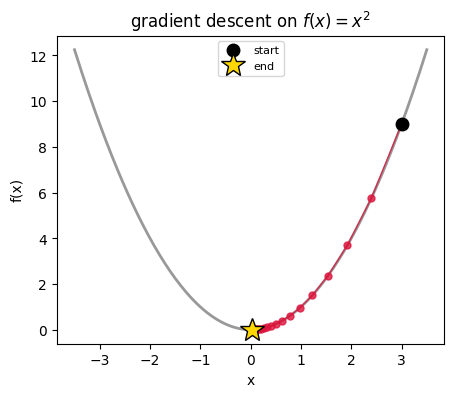

In [8]:
def gradient_descent(f, x0, lr=0.1, n_steps=20):
    """Walk downhill on f, starting from x0. Returns every point visited."""
    x = x0
    path = [x]
    for _ in range(n_steps):
        grad = numerical_gradient(f, x)
        x = x - lr * grad
        path.append(x)
    return np.array(path)


path = gradient_descent(f, x0=3.0, lr=0.1, n_steps=20)
print("ended at x =", round(path[-1], 5), " after", len(path) - 1, "steps")

ax = wu.plot_function(f, xlim=(-3.5, 3.5))
wu.plot_path_1d(f, path, ax=ax)
ax.set_title("gradient descent on $f(x) = x^2$")
plt.show()

## 4. The learning rate

$\eta$ is the first **hyperparameter** (user-defined, not learned) you'll deal with.

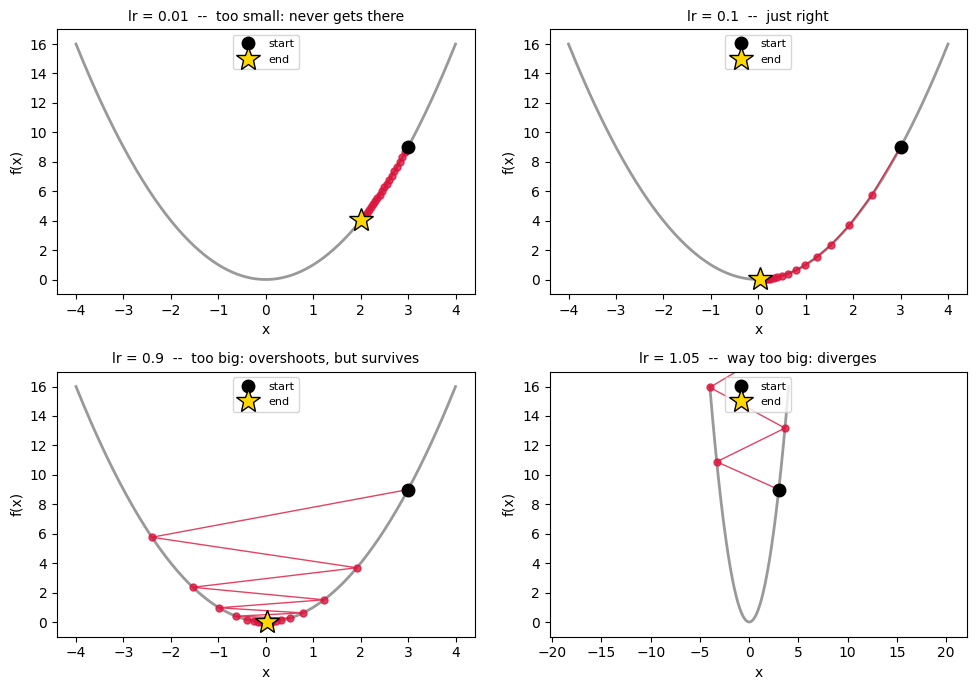

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
titles = ["too small: never gets there",
          "just right",
          "too big: overshoots, but survives",
          "way too big: diverges"]

for ax, lr, title in zip(axes.ravel(), [0.01, 0.1, 0.9, 1.05], titles):
    p = gradient_descent(f, x0=3.0, lr=lr, n_steps=20)
    wu.plot_function(f, xlim=(-4, 4), ax=ax)
    wu.plot_path_1d(f, p, ax=ax)
    ax.set_title(f"lr = {lr}  --  {title}", fontsize=10)
    ax.set_ylim(-1, 17)

plt.tight_layout()
plt.show()

With `lr = 1.05` every step lands
*further* from the minimum than the last one, and $f(x)$ grows without bound.

## 5. Two dimensions

Real models have more than one parameter. The only change is that `x` becomes
an array and the slope becomes a **gradient**: one slope per direction. Using partial derivatives:

$$\nabla f = \left[ \frac{\partial f}{\partial x_1},\ \frac{\partial f}{\partial x_2} \right]$$

We can reuse the code we already have -- we just loop over the
coordinates.

The update rule does not change:
$\mathbf{x} \leftarrow \mathbf{x} - \eta \nabla f$.

In [10]:
def numerical_gradient_nd(f, x, h=1e-5):
    """Gradient of f at the array x: one measured slope per coordinate."""
    grad = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = h
        grad[i] = (f(x + step) - f(x - step)) / (2 * h)
    return grad


def gradient_descent_nd(f, x0, lr=0.1, n_steps=30):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    for _ in range(n_steps):
        x = x - lr * numerical_gradient_nd(f, x)
        path.append(x.copy())
    return np.array(path)


def bowl(x):
    """A stretched bowl: steep in one direction, shallow in the other."""
    return x[0] ** 2 + 5 * x[1] ** 2

ended at [-0.  0.]


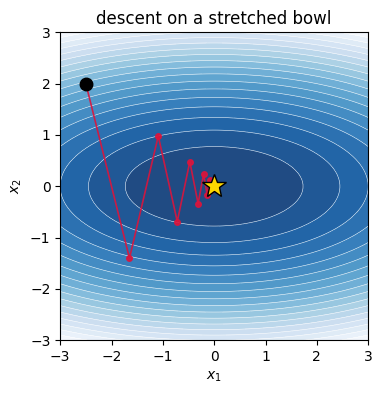

In [11]:
path2d = gradient_descent_nd(bowl, x0=[-2.5, 2.0], lr=0.17, n_steps=40)
print("ended at", path2d[-1].round(4))

ax = wu.plot_contour(bowl, xlim=(-3, 3), ylim=(-3, 3))
wu.plot_path_2d(path2d, ax=ax)
ax.set_title("descent on a stretched bowl")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.show()

Notice the zig-zag. The gradient points straight downhill *locally*, which is
not the same as pointing at the minimum. In the steep direction we overshoot
and bounce; in the shallow direction we creep. Optimizers exist to deal with it.

**Try:** change `bowl` to `x[0]**2 + 50*x[1]**2` and re-run. The same learning
rate now explodes. Lower `lr` until it converges again -- and then look at how
far along $x_1$ it got in 40 steps. Making the bowl steeper in *one* direction
made descent slower in the *other*.

## Local minima

The loss function isn't bound to be nice; in fact, it's usually a crazy terrain. If we're unlucky, we end up
in a local minima.

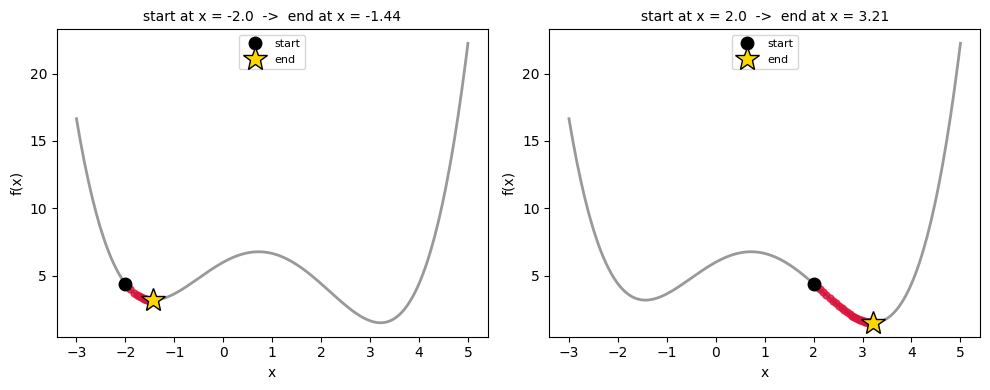

In [12]:
def bumpy(x):
    return 0.15 * x ** 4 - 0.5 * x ** 3 - x ** 2 + 2 * x + 6

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, x0 in zip(axes, [-2.0, 2.0]):
    p = gradient_descent(bumpy, x0=x0, lr=0.02, n_steps=60)
    wu.plot_function(bumpy, xlim=(-3, 5), ax=ax)
    wu.plot_path_1d(bumpy, p, ax=ax)
    ax.set_title(f"start at x = {x0}  ->  end at x = {p[-1]:.2f}", fontsize=10)
plt.tight_layout()
plt.show()

## Actual model: fitting a line

From "minimising a function" to "learning from data".

We have points $(x_i, y_i)$ and we want the line $y = wx + b$ that fits them.
The parameters we are free to choose are $w$ and $b$, so *they* are what we do
gradient descent on. The landscape we descend is the **loss**: the average
squared miss,

$$L(w, b) = \frac{1}{N}\sum_i \left( (w x_i + b) - y_i \right)^2$$

In [13]:
# --- the data: a noisy line with a true slope of 2 and intercept of -1 ---
x_data = np.linspace(-3, 3, 20)
y_data = 2.0 * x_data - 1.0 + np.random.normal(0, 1.0, size=20)


def loss(params):
    """params = [w, b]. How badly does this line fit the data?"""
    w, b = params
    predictions = w * x_data + b
    return np.mean((predictions - y_data) ** 2)

In [14]:
trail = gradient_descent_nd(loss, x0=[-1.0, 3.0], lr=0.1, n_steps=150)
w_fit, b_fit = trail[-1]
print(f"learned w = {w_fit:.3f} (true 2.0),  b = {b_fit:.3f} (true -1.0)")

learned w = 1.810 (true 2.0),  b = -0.431 (true -1.0)


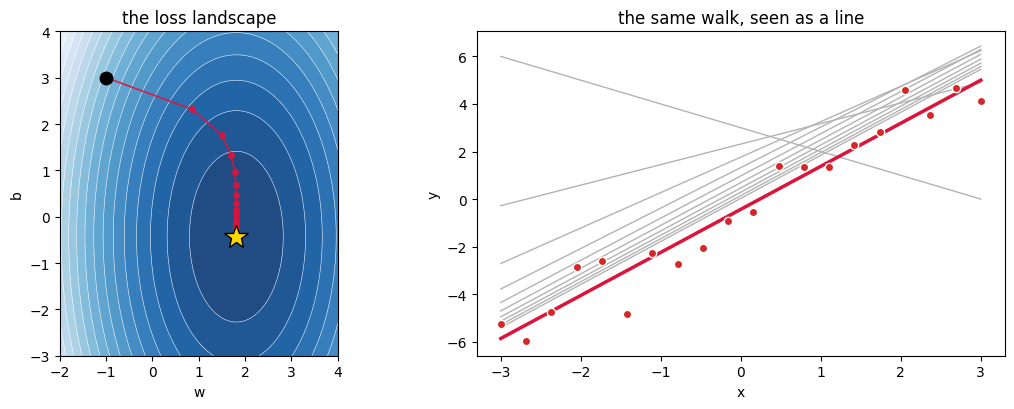

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# left: the loss landscape, with our walk across it
wu.plot_contour(loss, xlim=(-2, 4), ylim=(-3, 4), ax=ax1)
wu.plot_path_2d(trail, ax=ax1)
ax1.set_xlabel("w"); ax1.set_ylabel("b"); ax1.set_title("the loss landscape")

# right: the same walk, seen as a line moving through the data
ax2.scatter(x_data, y_data, c="#d62728", edgecolor="white", zorder=3)
for w, b in trail[:10]:          # the first ten steps, where the action is
    ax2.plot(x_data, w * x_data + b, color="0.7", lw=1)
ax2.plot(x_data, w_fit * x_data + b_fit, color="crimson", lw=2.5)
ax2.set_title("the same walk, seen as a line")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
plt.tight_layout()
plt.show()

Every grey line on the right is a dot on the left.
First the line mostly **rotates** (the path moves
sideways, changing `w`), then it **slides** down without turning (the path
drops vertically, changing only `b`). The slope is settled early because the
landscape is much steeper in the `w` direction -- the
contours are tightly packed horizontally.

We recover `w = 1.81`, not the 2.0 we used to generate the data. That
is not a failure to converge -- 1.81 really is the best-fitting slope *for these
20 noisy points*. The model fits the data it was given, not the truth behind it.